# Retail Sales Forecasting with Machine Learning

## Project Overview

This project develops a machine learning-based sales forecasting system using historical retail transaction data.

The objective is to identify temporal sales patterns and use historical information to predict future weekly sales.

The project focuses on time-aware feature engineering, chronological validation, baseline forecasting, machine learning models, and forecast evaluation.

## Objectives

- Understand historical sales patterns
- Analyze trends and seasonality
- Create time-based features
- Engineer lag and rolling features
- Build baseline forecasting models
- Compare machine learning models
- Evaluate forecasting performance using time-aware validation
- Identify important predictors of future sales

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit

In [3]:
import glob

glob.glob("/content/*.csv")

['/content/train - Walmart Sales Forecast.csv']

In [5]:
df = pd.read_csv("/content/train - Walmart Sales Forecast.csv")

In [6]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [7]:
df.shape

(421570, 5)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [9]:
df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='object')

In [10]:
df.describe()

,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [11]:
df["Date"] = pd.to_datetime(df["Date"])

In [12]:
df["Date"].min(), df["Date"].max()

(Timestamp('2010-02-05 00:00:00'), Timestamp('2012-10-26 00:00:00'))

In [13]:
df.dtypes

,0
Store,int64
Dept,int64
Date,datetime64[ns]
Weekly_Sales,float64
IsHoliday,bool


In [14]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0


In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
weekly_sales = (
    df.groupby("Date")["Weekly_Sales"]
    .sum()
    .reset_index()
    .sort_values("Date")
)

In [17]:
weekly_sales.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [18]:
weekly_sales.shape

(143, 2)

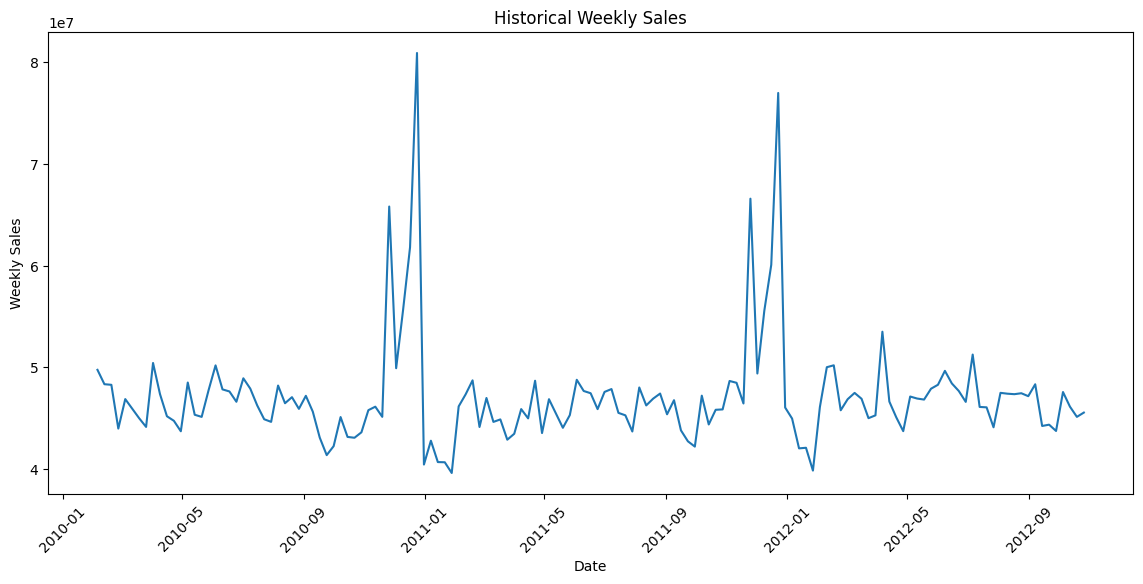

In [19]:
plt.figure(figsize=(14, 6))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Weekly_Sales"]
)

plt.title("Historical Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.xticks(rotation=45)

plt.show()

In [20]:
weekly_sales["Year"] = (
    weekly_sales["Date"]
    .dt.year
)

weekly_sales["Month"] = (
    weekly_sales["Date"]
    .dt.month
)

In [21]:
monthly_sales = (
    weekly_sales
    .groupby(["Year", "Month"])["Weekly_Sales"]
    .mean()
    .reset_index()
)

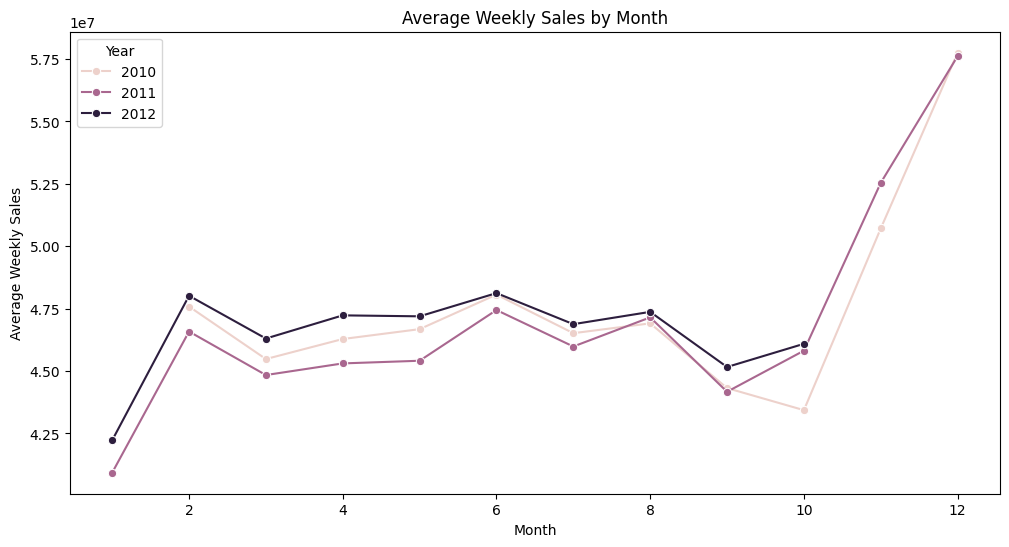

In [22]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Weekly_Sales",
    hue="Year",
    marker="o"
)

plt.title("Average Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")

plt.show()

In [23]:
weekly_sales["Year"] = weekly_sales["Date"].dt.year
weekly_sales["Month"] = weekly_sales["Date"].dt.month
weekly_sales["Week"] = weekly_sales["Date"].dt.isocalendar().week.astype(int)
weekly_sales["Quarter"] = weekly_sales["Date"].dt.quarter

In [24]:
weekly_sales["TimeIndex"] = np.arange(
    len(weekly_sales)
)

In [25]:
weekly_sales["Lag_1"] = (
    weekly_sales["Weekly_Sales"]
    .shift(1)
)

weekly_sales["Lag_4"] = (
    weekly_sales["Weekly_Sales"]
    .shift(4)
)

weekly_sales["Lag_12"] = (
    weekly_sales["Weekly_Sales"]
    .shift(12)
)

weekly_sales["Lag_52"] = (
    weekly_sales["Weekly_Sales"]
    .shift(52)
)

In [26]:
weekly_sales["Rolling_4"] = (
    weekly_sales["Weekly_Sales"]
    .shift(1)
    .rolling(4)
    .mean()
)

weekly_sales["Rolling_12"] = (
    weekly_sales["Weekly_Sales"]
    .shift(1)
    .rolling(12)
    .mean()
)

In [27]:
weekly_sales.head(15)

,Date,Weekly_Sales,Year,Month,Week,Quarter,TimeIndex,Lag_1,Lag_4,Lag_12,Lag_52,Rolling_4,Rolling_12
0,2010-02-05,49750740.50,2010,2,5,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-02-12,48336677.63,2010,2,6,1,1,49750740.50,NaN,NaN,NaN,NaN,NaN
2,2010-02-19,48276993.78,2010,2,7,1,2,48336677.63,NaN,NaN,NaN,NaN,NaN
3,2010-02-26,43968571.13,2010,2,8,1,3,48276993.78,NaN,NaN,NaN,NaN,NaN
4,2010-03-05,46871470.30,2010,3,9,1,4,43968571.13,49750740.50,NaN,NaN,4.758325e+07,NaN
5,2010-03-12,45925396.51,2010,3,10,1,5,46871470.30,48336677.63,NaN,NaN,4.686343e+07,NaN
6,2010-03-19,44988974.64,2010,3,11,1,6,45925396.51,48276993.78,NaN,NaN,4.626061e+07,NaN
7,2010-03-26,44133961.05,2010,3,12,1,7,44988974.64,43968571.13,NaN,NaN,4.543860e+07,NaN
8,2010-04-02,50423831.26,2010,4,13,2,8,44133961.05,46871470.30,NaN,NaN,4.547995e+07,NaN
9,2010-04-09,47365290.44,2010,4,14,2,9,50423831.26,45925396.51,NaN,NaN,4.636804e+07,NaN


In [28]:
weekly_sales.isnull().sum()

,0
Date,0
Weekly_Sales,0
Year,0
Month,0
Week,0
Quarter,0
TimeIndex,0
Lag_1,1
Lag_4,4
Lag_12,12


In [29]:
weekly_sales = weekly_sales.dropna().reset_index(drop=True)

In [30]:
weekly_sales.shape

(91, 13)

In [31]:
numeric_cols = [
    "Weekly_Sales",
    "Lag_1",
    "Lag_4",
    "Lag_12",
    "Lag_52",
    "Rolling_4",
    "Rolling_12",
    "TimeIndex"
]

correlation = (
    weekly_sales[numeric_cols]
    .corr()["Weekly_Sales"]
    .sort_values(ascending=False)
)

correlation

,Weekly_Sales
Weekly_Sales,1.000000
Lag_52,0.926157
Lag_1,0.352142
Rolling_4,0.323285
Lag_4,0.206794
TimeIndex,0.064225
Rolling_12,0.049817
Lag_12,-0.087724


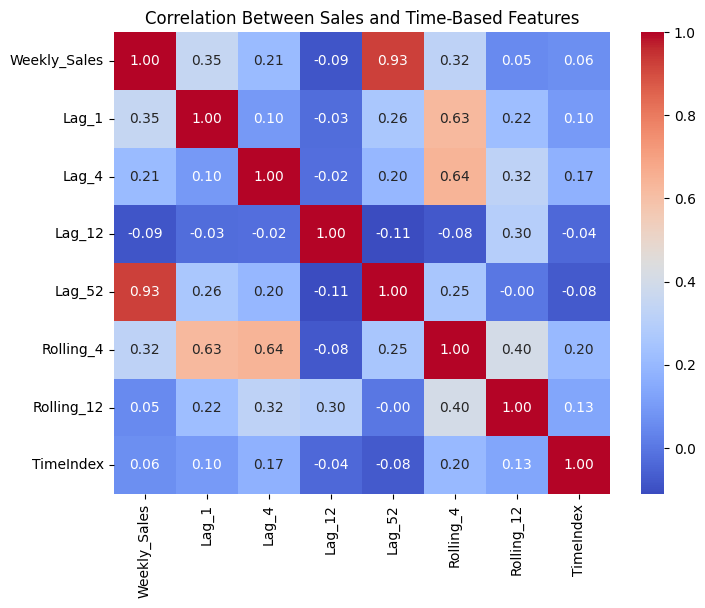

In [32]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    weekly_sales[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Sales and Time-Based Features")

plt.show()

In [33]:
split_index = int(
    len(weekly_sales) * 0.80
)

train = weekly_sales.iloc[:split_index].copy()
test = weekly_sales.iloc[split_index:].copy()

print("Training:", train.shape)
print("Testing :", test.shape)

Training: (72, 13)
Testing : (19, 13)


In [34]:
print(
    "Train period:",
    train["Date"].min(),
    "to",
    train["Date"].max()
)

print(
    "Test period:",
    test["Date"].min(),
    "to",
    test["Date"].max()
)

Train period: 2011-02-04 00:00:00 to 2012-06-15 00:00:00
Test period: 2012-06-22 00:00:00 to 2012-10-26 00:00:00


In [35]:
test["Naive_Prediction"] = test["Lag_1"]

In [36]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

naive_mae = mean_absolute_error(
    test["Weekly_Sales"],
    test["Naive_Prediction"]
)

naive_rmse = np.sqrt(
    mean_squared_error(
        test["Weekly_Sales"],
        test["Naive_Prediction"]
    )
)

naive_r2 = r2_score(
    test["Weekly_Sales"],
    test["Naive_Prediction"]
)

print(f"Naive MAE : {naive_mae:,.2f}")
print(f"Naive RMSE: {naive_rmse:,.2f}")
print(f"Naive R²  : {naive_r2:.4f}")

Naive MAE : 1,591,989.17
Naive RMSE: 2,316,135.61
Naive R²  : -0.7334


In [37]:
features = [
    "Year",
    "Month",
    "Week",
    "Quarter",
    "TimeIndex",
    "Lag_1",
    "Lag_4",
    "Lag_12",
    "Lag_52",
    "Rolling_4",
    "Rolling_12"
]

In [38]:
X_train = train[features]
y_train = train["Weekly_Sales"]

X_test = test[features]
y_test = test["Weekly_Sales"]

In [40]:
rf_forecast = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

In [41]:
rf_forecast.fit(
    X_train,
    y_train
)

RandomForestRegressor(max_depth=10, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [42]:
rf_pred = rf_forecast.predict(
    X_test
)

In [43]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print(f"Random Forest MAE : {rf_mae:,.2f}")
print(f"Random Forest RMSE: {rf_rmse:,.2f}")
print(f"Random Forest R²  : {rf_r2:.4f}")

Random Forest MAE : 1,119,211.33
Random Forest RMSE: 1,404,506.67
Random Forest R²  : 0.3626


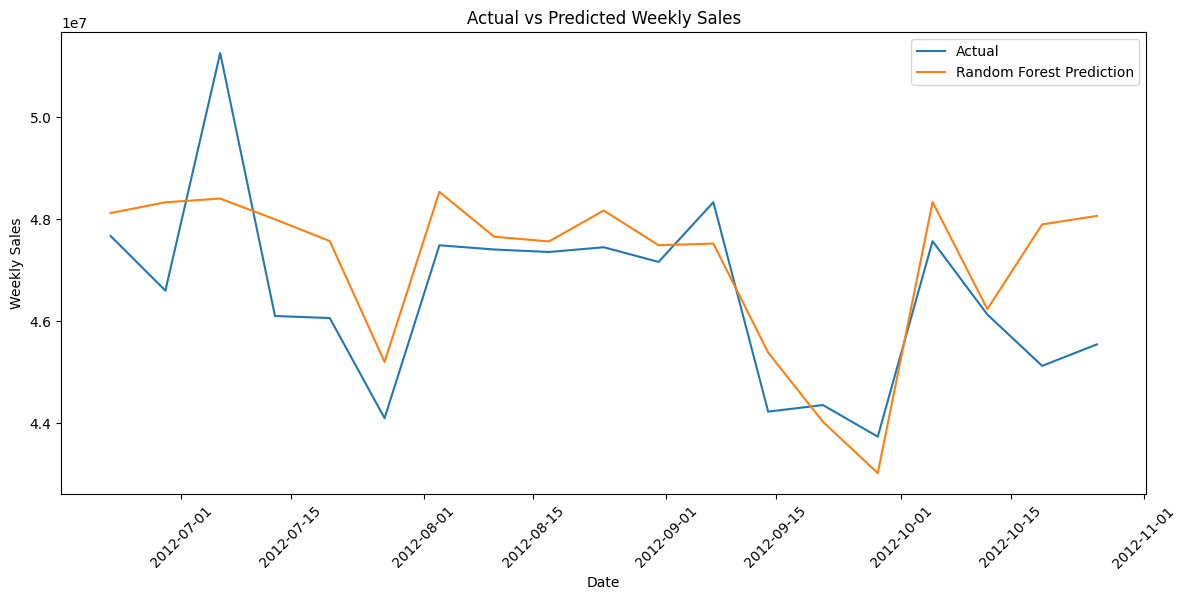

In [44]:
plt.figure(figsize=(14, 6))

plt.plot(
    test["Date"],
    y_test.values,
    label="Actual"
)

plt.plot(
    test["Date"],
    rf_pred,
    label="Random Forest Prediction"
)

plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()

plt.xticks(rotation=45)

plt.show()

In [45]:
df.shape

(421570, 5)

In [46]:
weekly_sales.shape

(91, 13)

In [47]:
correlation

,Weekly_Sales
Weekly_Sales,1.000000
Lag_52,0.926157
Lag_1,0.352142
Rolling_4,0.323285
Lag_4,0.206794
TimeIndex,0.064225
Rolling_12,0.049817
Lag_12,-0.087724


In [49]:
!pip install xgboost -q

In [51]:
xgb_forecast = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

In [52]:
xgb_forecast.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [53]:
xgb_pred = xgb_forecast.predict(
    X_test
)

In [54]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

print(f"XGBoost MAE : {xgb_mae:,.2f}")
print(f"XGBoost RMSE: {xgb_rmse:,.2f}")
print(f"XGBoost R²  : {xgb_r2:.4f}")

XGBoost MAE : 1,383,454.44
XGBoost RMSE: 1,691,720.03
XGBoost R²  : 0.0752


In [55]:
forecast_comparison = pd.DataFrame({
    "Model": [
        "Naive Forecast",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        naive_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        naive_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        naive_r2,
        rf_r2,
        xgb_r2
    ]
})

forecast_comparison

,Model,MAE,RMSE,R2
0,Naive Forecast,1.591989e+06,2.316136e+06,-0.733442
1,Random Forest,1.119211e+06,1.404507e+06,0.362575
2,XGBoost,1.383454e+06,1.691720e+06,0.075220


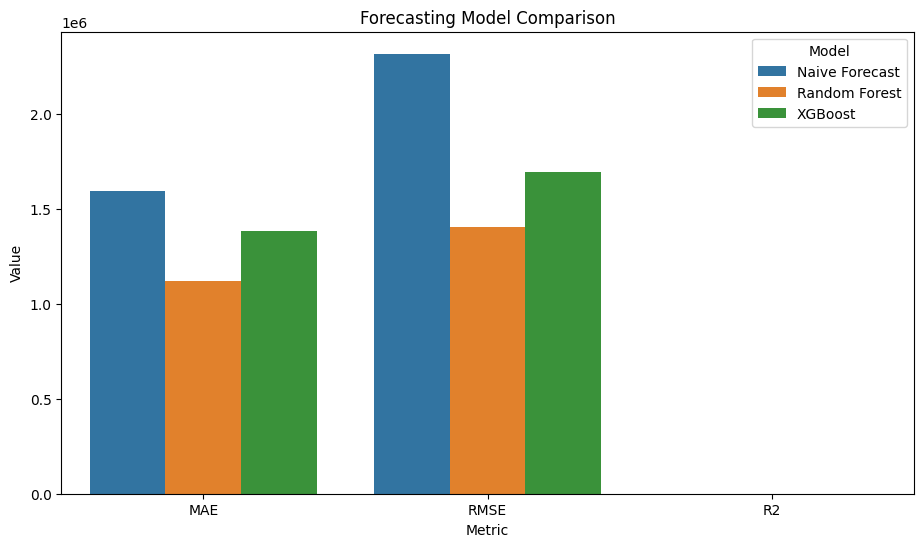

In [56]:
comparison_long = forecast_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Value",
    hue="Model"
)

plt.title("Forecasting Model Comparison")
plt.show()

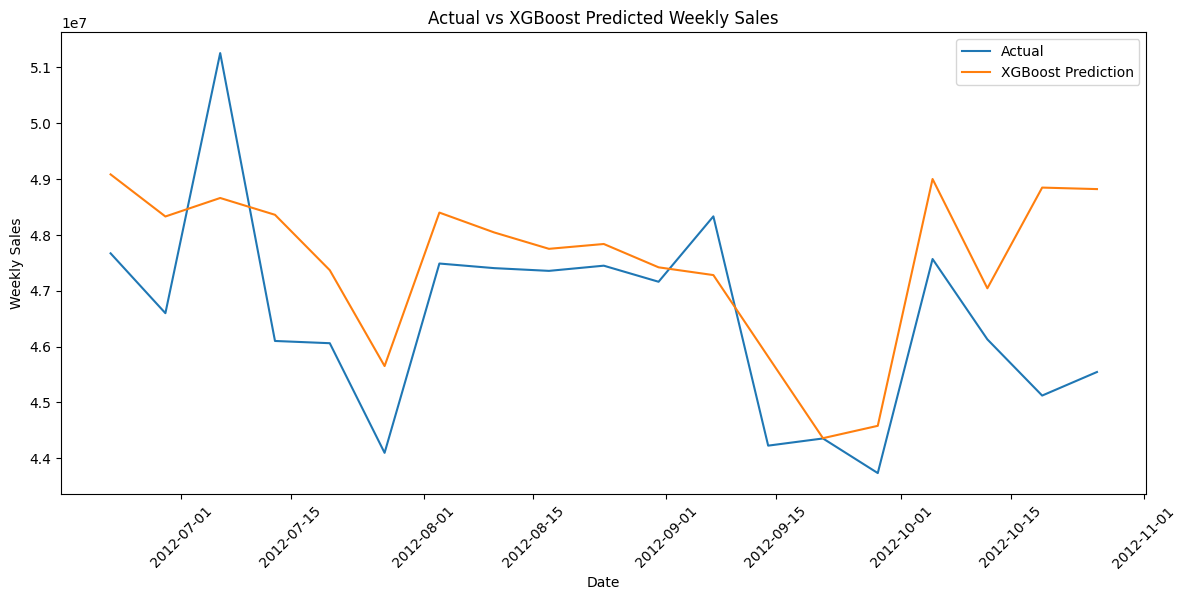

In [57]:
plt.figure(figsize=(14, 6))

plt.plot(
    test["Date"],
    y_test.values,
    label="Actual"
)

plt.plot(
    test["Date"],
    xgb_pred,
    label="XGBoost Prediction"
)

plt.title("Actual vs XGBoost Predicted Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()

plt.xticks(rotation=45)

plt.show()

In [58]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_forecast.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
8,Lag_52,0.387674
2,Week,0.234864
1,Month,0.101607
5,Lag_1,0.067561
4,TimeIndex,0.048503
6,Lag_4,0.042369
7,Lag_12,0.036151
0,Year,0.033410
9,Rolling_4,0.019538
10,Rolling_12,0.016793


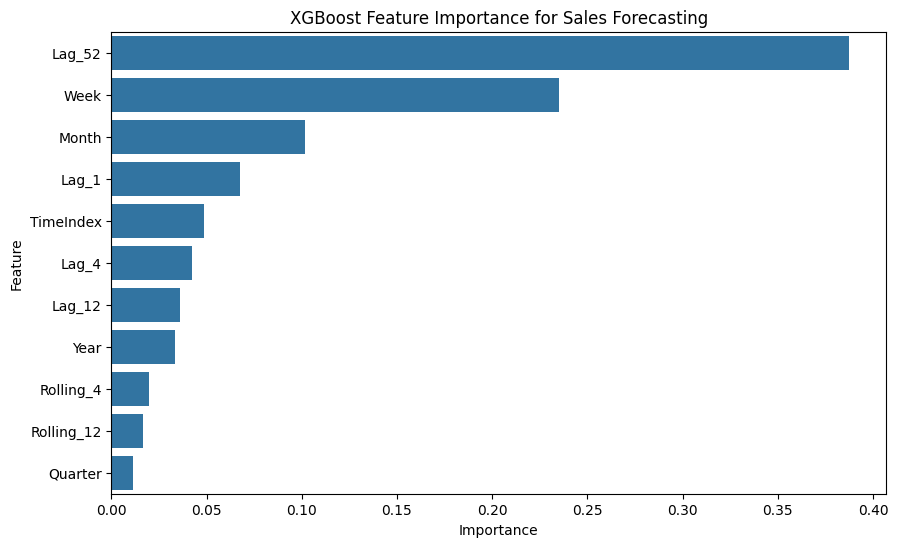

In [59]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance for Sales Forecasting")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [61]:
tscv = TimeSeriesSplit(
    n_splits=5
)

In [62]:
rf_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(weekly_sales),
    start=1
):
    train_fold = weekly_sales.iloc[train_idx]
    val_fold = weekly_sales.iloc[val_idx]

    X_train_fold = train_fold[features]
    y_train_fold = train_fold["Weekly_Sales"]

    X_val_fold = val_fold[features]
    y_val_fold = val_fold["Weekly_Sales"]

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    pred = model.predict(
        X_val_fold
    )

    fold_mae = mean_absolute_error(
        y_val_fold,
        pred
    )

    fold_rmse = np.sqrt(
        mean_squared_error(
            y_val_fold,
            pred
        )
    )

    fold_r2 = r2_score(
        y_val_fold,
        pred
    )

    rf_cv_results.append({
        "Fold": fold,
        "MAE": fold_mae,
        "RMSE": fold_rmse,
        "R2": fold_r2
    })

In [63]:
rf_cv_results = pd.DataFrame(
    rf_cv_results
)

rf_cv_results

,Fold,MAE,RMSE,R2
0,1,1.362716e+06,1.656402e+06,-0.514514
1,2,3.989587e+06,6.725481e+06,-0.051963
2,3,3.096129e+06,5.228057e+06,0.600722
3,4,1.540585e+06,2.280391e+06,0.029471
4,5,1.021371e+06,1.348923e+06,0.164522


In [64]:
print(
    f"Mean MAE : {rf_cv_results['MAE'].mean():,.2f}"
)

print(
    f"Mean RMSE: {rf_cv_results['RMSE'].mean():,.2f}"
)

print(
    f"Mean R²  : {rf_cv_results['R2'].mean():.4f}"
)

Mean MAE : 2,202,077.72
Mean RMSE: 3,447,850.48
Mean R²  : 0.0456


In [65]:
print(
    f"MAE Std : {rf_cv_results['MAE'].std():,.2f}"
)

print(
    f"RMSE Std: {rf_cv_results['RMSE'].std():,.2f}"
)

print(
    f"R² Std  : {rf_cv_results['R2'].std():.4f}"
)

MAE Std : 1,277,760.38
RMSE Std: 2,392,161.52
R² Std  : 0.4018


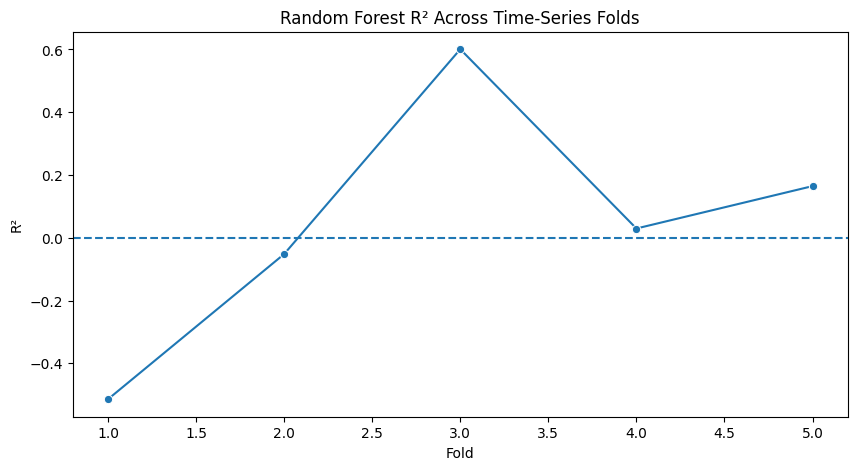

In [66]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=rf_cv_results,
    x="Fold",
    y="R2",
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Random Forest R² Across Time-Series Folds")
plt.xlabel("Fold")
plt.ylabel("R²")

plt.show()

In [67]:
test_results = test[
    ["Date", "Weekly_Sales"]
].copy()

test_results["Prediction"] = rf_pred

test_results["Error"] = (
    test_results["Weekly_Sales"]
    - test_results["Prediction"]
)

test_results["AbsoluteError"] = (
    test_results["Error"]
    .abs()
)

In [68]:
largest_errors = (
    test_results
    .sort_values(
        "AbsoluteError",
        ascending=False
    )
    .head(10)
)

largest_errors

,Date,Weekly_Sales,Prediction,Error,AbsoluteError
74,2012-07-06,51253021.88,4.840174e+07,2.851277e+06,2.851277e+06
89,2012-10-19,45122410.57,4.789506e+07,-2.772645e+06,2.772645e+06
90,2012-10-26,45544116.29,4.806171e+07,-2.517595e+06,2.517595e+06
75,2012-07-13,46099732.10,4.799528e+07,-1.895543e+06,1.895543e+06
73,2012-06-29,46597112.12,4.832797e+07,-1.730862e+06,1.730862e+06
76,2012-07-20,46059543.45,4.756839e+07,-1.508844e+06,1.508844e+06
84,2012-09-14,44226038.65,4.538362e+07,-1.157581e+06,1.157581e+06
77,2012-07-27,44097154.97,4.519891e+07,-1.101752e+06,1.101752e+06
78,2012-08-03,47485899.56,4.853326e+07,-1.047357e+06,1.047357e+06
83,2012-09-07,48330059.31,4.751942e+07,8.106359e+05,8.106359e+05


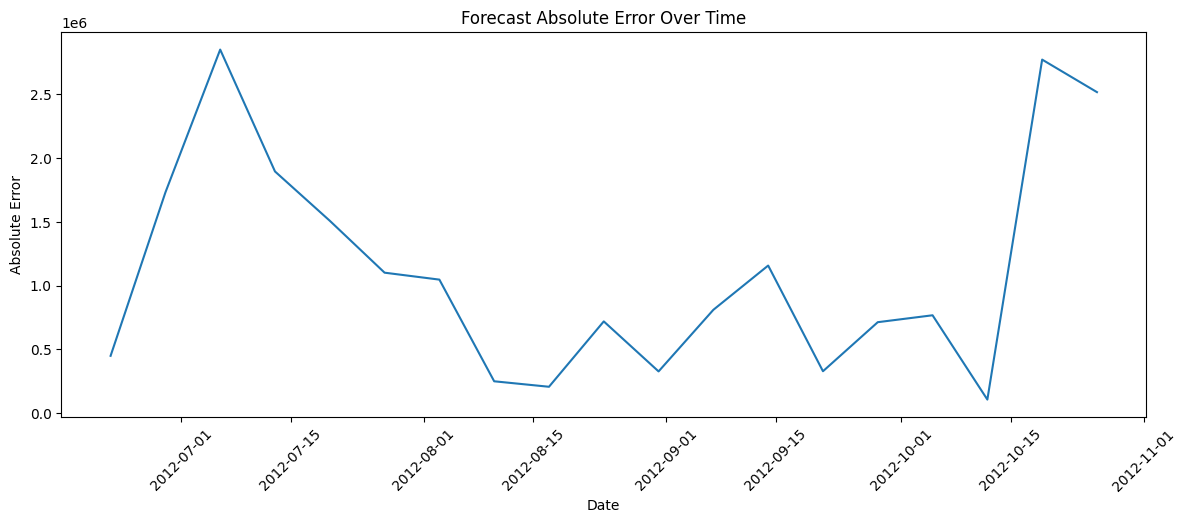

In [69]:
plt.figure(figsize=(14, 5))

plt.plot(
    test_results["Date"],
    test_results["AbsoluteError"]
)

plt.title("Forecast Absolute Error Over Time")
plt.xlabel("Date")
plt.ylabel("Absolute Error")

plt.xticks(rotation=45)

plt.show()

In [70]:
rf_cv_results

,Fold,MAE,RMSE,R2
0,1,1.362716e+06,1.656402e+06,-0.514514
1,2,3.989587e+06,6.725481e+06,-0.051963
2,3,3.096129e+06,5.228057e+06,0.600722
3,4,1.540585e+06,2.280391e+06,0.029471
4,5,1.021371e+06,1.348923e+06,0.164522


In [71]:
df_ts = df.copy()

df_ts["Date"] = pd.to_datetime(df_ts["Date"])

df_ts = df_ts.sort_values(
    ["Store", "Dept", "Date"]
).reset_index(drop=True)

df_ts.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [72]:
df_ts.shape

(421570, 5)

In [73]:
df_ts["Year"] = df_ts["Date"].dt.year
df_ts["Month"] = df_ts["Date"].dt.month
df_ts["Week"] = df_ts["Date"].dt.isocalendar().week.astype(int)
df_ts["Quarter"] = df_ts["Date"].dt.quarter
df_ts["TimeIndex"] = (
    df_ts["Date"] - df_ts["Date"].min()
).dt.days

In [74]:
group_cols = ["Store", "Dept"]

df_ts["Lag_1"] = (
    df_ts
    .groupby(group_cols)["Weekly_Sales"]
    .shift(1)
)

df_ts["Lag_4"] = (
    df_ts
    .groupby(group_cols)["Weekly_Sales"]
    .shift(4)
)

df_ts["Lag_12"] = (
    df_ts
    .groupby(group_cols)["Weekly_Sales"]
    .shift(12)
)

df_ts["Lag_52"] = (
    df_ts
    .groupby(group_cols)["Weekly_Sales"]
    .shift(52)
)

In [75]:
df_ts["Rolling_4"] = (
    df_ts
    .groupby(group_cols)["Weekly_Sales"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(4)
        .mean()
    )
)

df_ts["Rolling_12"] = (
    df_ts
    .groupby(group_cols)["Weekly_Sales"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(12)
        .mean()
    )
)

In [76]:
forecast_features = [
    "Store",
    "Dept",
    "Year",
    "Month",
    "Week",
    "Quarter",
    "TimeIndex",
    "IsHoliday",
    "Lag_1",
    "Lag_4",
    "Lag_12",
    "Lag_52",
    "Rolling_4",
    "Rolling_12"
]

In [77]:
df_ts[
    forecast_features + ["Weekly_Sales"]
].head(10)

,Store,Dept,Year,Month,Week,Quarter,TimeIndex,IsHoliday,Lag_1,Lag_4,Lag_12,Lag_52,Rolling_4,Rolling_12,Weekly_Sales
0,1,1,2010,2,5,1,0,False,NaN,NaN,NaN,NaN,NaN,NaN,24924.50
1,1,1,2010,2,6,1,7,True,24924.50,NaN,NaN,NaN,NaN,NaN,46039.49
2,1,1,2010,2,7,1,14,False,46039.49,NaN,NaN,NaN,NaN,NaN,41595.55
3,1,1,2010,2,8,1,21,False,41595.55,NaN,NaN,NaN,NaN,NaN,19403.54
4,1,1,2010,3,9,1,28,False,19403.54,24924.50,NaN,NaN,32990.7700,NaN,21827.90
5,1,1,2010,3,10,1,35,False,21827.90,46039.49,NaN,NaN,32216.6200,NaN,21043.39
6,1,1,2010,3,11,1,42,False,21043.39,41595.55,NaN,NaN,25967.5950,NaN,22136.64
7,1,1,2010,3,12,1,49,False,22136.64,19403.54,NaN,NaN,21102.8675,NaN,26229.21
8,1,1,2010,4,13,2,56,False,26229.21,21827.90,NaN,NaN,22809.2850,NaN,57258.43
9,1,1,2010,4,14,2,63,False,57258.43,21043.39,NaN,NaN,31666.9175,NaN,42960.91


In [78]:
df_ts[forecast_features].isnull().sum()

,0
Store,0
Dept,0
Year,0
Month,0
Week,0
Quarter,0
TimeIndex,0
IsHoliday,0
Lag_1,3331
Lag_4,13134


In [79]:
df_model = df_ts.dropna(
    subset=[
        "Lag_1",
        "Lag_4",
        "Lag_12",
        "Lag_52",
        "Rolling_4",
        "Rolling_12"
    ]
).copy()

In [80]:
print("Original rows:", len(df_ts))
print("Model rows   :", len(df_model))

Original rows: 421570
Model rows   : 261083


In [81]:
split_date = (
    df_model["Date"]
    .quantile(0.80)
)

print("Split date:", split_date)

Split date: 2012-06-29 00:00:00


In [82]:
train_ts = df_model[
    df_model["Date"] <= split_date
].copy()

In [83]:
test_ts = df_model[
    df_model["Date"] > split_date
].copy()

In [84]:
print("Training rows:", len(train_ts))
print("Testing rows :", len(test_ts))

Training rows: 211666
Testing rows : 49417


In [85]:
print(
    "Train period:",
    train_ts["Date"].min(),
    "to",
    train_ts["Date"].max()
)

print(
    "Test period:",
    test_ts["Date"].min(),
    "to",
    test_ts["Date"].max()
)

Train period: 2011-02-04 00:00:00 to 2012-06-29 00:00:00
Test period: 2012-07-06 00:00:00 to 2012-10-26 00:00:00


In [86]:
X_train = train_ts[forecast_features]
y_train = train_ts["Weekly_Sales"]

X_test = test_ts[forecast_features]
y_test = test_ts["Weekly_Sales"]

In [87]:
rf_forecast_v2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [88]:
rf_forecast_v2.fit(
    X_train,
    y_train
)

RandomForestRegressor(max_depth=15, min_samples_leaf=2, n_estimators=200,
                      n_jobs=-1, random_state=42)

In [89]:
rf_pred_v2 = rf_forecast_v2.predict(
    X_test
)

In [93]:
rf_mae_v2 = mean_absolute_error(
    y_test,
    rf_pred_v2
)

rf_rmse_v2 = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred_v2
    )
)

rf_r2_v2 = r2_score(
    y_test,
    rf_pred_v2
)

print(
    f"Random Forest MAE : {rf_mae_v2:,.2f}"
)

print(
    f"Random Forest RMSE: {rf_rmse_v2:,.2f}"
)

print(
    f"Random Forest R²  : {rf_r2_v2:.4f}"
)

Random Forest MAE : 1,227.39
Random Forest RMSE: 2,538.34
Random Forest R²  : 0.9868


In [90]:
feature_importance_v2 = pd.DataFrame({
    "Feature": forecast_features,
    "Importance": rf_forecast_v2.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance_v2

,Feature,Importance
11,Lag_52,0.802761
8,Lag_1,0.146897
12,Rolling_4,0.034518
13,Rolling_12,0.003966
9,Lag_4,0.003656
10,Lag_12,0.002093
1,Dept,0.001596
4,Week,0.001371
6,TimeIndex,0.001323
0,Store,0.000845


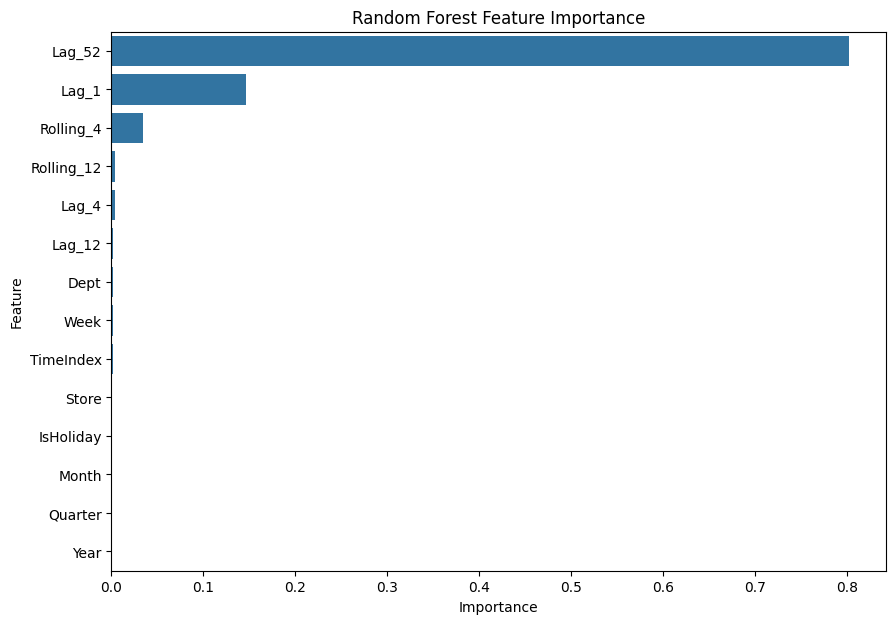

In [91]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_v2,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [92]:
df_model.shape

(261083, 16)

In [94]:
naive_pred_v2 = X_test["Lag_1"]

naive_mae_v2 = mean_absolute_error(
    y_test,
    naive_pred_v2
)

naive_rmse_v2 = np.sqrt(
    mean_squared_error(
        y_test,
        naive_pred_v2
    )
)

naive_r2_v2 = r2_score(
    y_test,
    naive_pred_v2
)

print(f"Naive MAE : {naive_mae_v2:,.2f}")
print(f"Naive RMSE: {naive_rmse_v2:,.2f}")
print(f"Naive R²  : {naive_r2_v2:.4f}")

Naive MAE : 1,574.39
Naive RMSE: 3,513.11
Naive R²  : 0.9747


In [95]:
xgb_forecast_v2 = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_forecast_v2.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [96]:
xgb_pred_v2 = xgb_forecast_v2.predict(
    X_test
)

In [97]:
xgb_mae_v2 = mean_absolute_error(
    y_test,
    xgb_pred_v2
)

xgb_rmse_v2 = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred_v2
    )
)

xgb_r2_v2 = r2_score(
    y_test,
    xgb_pred_v2
)

print(f"XGBoost MAE : {xgb_mae_v2:,.2f}")
print(f"XGBoost RMSE: {xgb_rmse_v2:,.2f}")
print(f"XGBoost R²  : {xgb_r2_v2:.4f}")

XGBoost MAE : 1,254.22
XGBoost RMSE: 2,587.94
XGBoost R²  : 0.9862


In [98]:
forecast_comparison_v2 = pd.DataFrame({
    "Model": [
        "Naive Forecast",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        naive_mae_v2,
        rf_mae_v2,
        xgb_mae_v2
    ],
    "RMSE": [
        naive_rmse_v2,
        rf_rmse_v2,
        xgb_rmse_v2
    ],
    "R2": [
        naive_r2_v2,
        rf_r2_v2,
        xgb_r2_v2
    ]
})

forecast_comparison_v2

,Model,MAE,RMSE,R2
0,Naive Forecast,1574.391172,3513.106584,0.974653
1,Random Forest,1227.394794,2538.344055,0.986767
2,XGBoost,1254.224660,2587.943091,0.986245


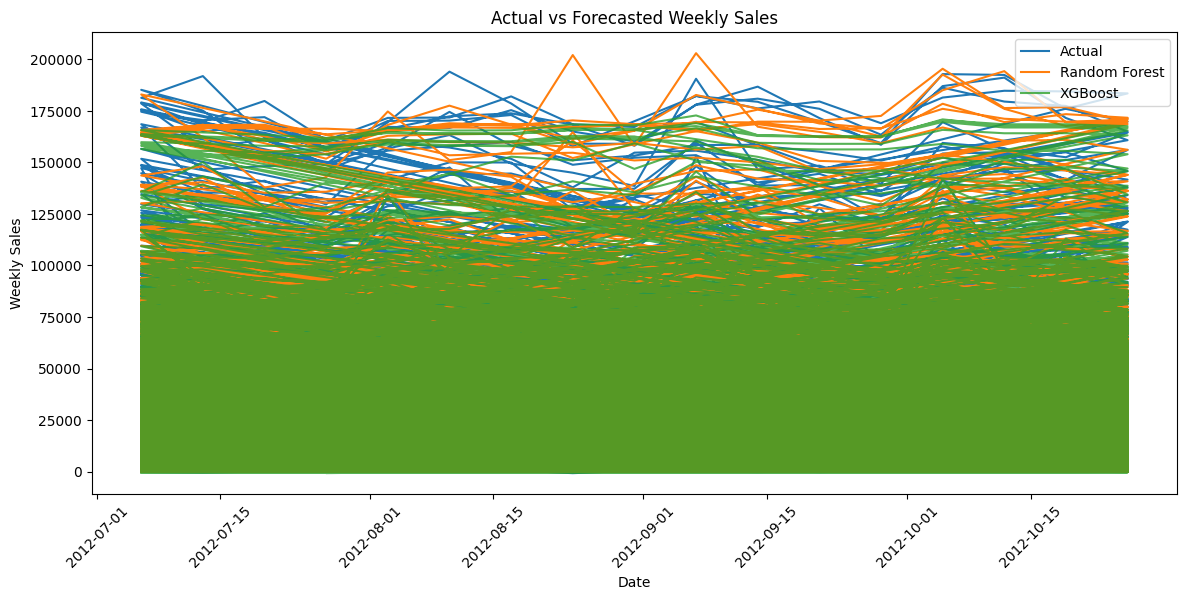

In [99]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_ts["Date"],
    y_test.values,
    label="Actual"
)

plt.plot(
    test_ts["Date"],
    rf_pred_v2,
    label="Random Forest"
)

plt.plot(
    test_ts["Date"],
    xgb_pred_v2,
    label="XGBoost",
    alpha=0.8
)

plt.title("Actual vs Forecasted Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()

plt.xticks(rotation=45)

plt.show()

In [100]:
cv_data = df_model.sort_values(
    ["Date", "Store", "Dept"]
).reset_index(drop=True)

In [101]:
tscv = TimeSeriesSplit(
    n_splits=5
)

In [102]:
rf_cv_results_v2 = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(cv_data),
    start=1
):
    train_fold = cv_data.iloc[train_idx]
    val_fold = cv_data.iloc[val_idx]

    X_train_fold = train_fold[forecast_features]
    y_train_fold = train_fold["Weekly_Sales"]

    X_val_fold = val_fold[forecast_features]
    y_val_fold = val_fold["Weekly_Sales"]

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    pred_fold = model.predict(
        X_val_fold
    )

    fold_mae = mean_absolute_error(
        y_val_fold,
        pred_fold
    )

    fold_rmse = np.sqrt(
        mean_squared_error(
            y_val_fold,
            pred_fold
        )
    )

    fold_r2 = r2_score(
        y_val_fold,
        pred_fold
    )

    rf_cv_results_v2.append({
        "Fold": fold,
        "MAE": fold_mae,
        "RMSE": fold_rmse,
        "R2": fold_r2
    })

In [103]:
rf_cv_results_v2 = pd.DataFrame(
    rf_cv_results_v2
)

rf_cv_results_v2

,Fold,MAE,RMSE,R2
0,1,1336.263804,2847.643546,0.983173
1,2,1948.048752,7897.788183,0.897008
2,3,1700.988434,3786.976632,0.974314
3,4,1491.724879,3393.292421,0.977023
4,5,1206.149552,2513.254114,0.986856


In [104]:
print(
    f"Mean MAE : {rf_cv_results_v2['MAE'].mean():,.2f}"
)

print(
    f"Mean RMSE: {rf_cv_results_v2['RMSE'].mean():,.2f}"
)

print(
    f"Mean R²  : {rf_cv_results_v2['R2'].mean():.4f}"
)

Mean MAE : 1,536.64
Mean RMSE: 4,087.79
Mean R²  : 0.9637


In [105]:
print(
    f"MAE Std : {rf_cv_results_v2['MAE'].std():,.2f}"
)

print(
    f"RMSE Std: {rf_cv_results_v2['RMSE'].std():,.2f}"
)

print(
    f"R² Std  : {rf_cv_results_v2['R2'].std():.4f}"
)

MAE Std : 294.81
RMSE Std: 2,185.52
R² Std  : 0.0376


In [106]:
fold_summary = rf_cv_results_v2.copy()

fold_summary["MAE_Ratio"] = (
    fold_summary["MAE"] /
    fold_summary["MAE"].mean()
)

fold_summary["RMSE_Ratio"] = (
    fold_summary["RMSE"] /
    fold_summary["RMSE"].mean()
)

fold_summary

,Fold,MAE,RMSE,R2,MAE_Ratio,RMSE_Ratio
0,1,1336.263804,2847.643546,0.983173,0.869604,0.696622
1,2,1948.048752,7897.788183,0.897008,1.267737,1.932043
2,3,1700.988434,3786.976632,0.974314,1.106957,0.926412
3,4,1491.724879,3393.292421,0.977023,0.970774,0.830104
4,5,1206.149552,2513.254114,0.986856,0.784929,0.614820


In [107]:
worst_fold = (
    fold_summary
    .sort_values("RMSE", ascending=False)
    .iloc[0]
)

worst_fold

,1
Fold,2.000000
MAE,1948.048752
RMSE,7897.788183
R2,0.897008
MAE_Ratio,1.267737
RMSE_Ratio,1.932043


In [108]:
final_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(
    X_train,
    y_train
)

RandomForestRegressor(max_depth=15, min_samples_leaf=2, n_estimators=300,
                      n_jobs=-1, random_state=42)

In [117]:
final_pred = final_rf_model.predict(
    X_test
)

In [110]:
final_forecast = test_ts[
    ["Store", "Dept", "Date", "Weekly_Sales"]
].copy()

final_forecast["Predicted_Sales"] = final_pred

final_forecast["Absolute_Error"] = (
    final_forecast["Weekly_Sales"]
    - final_forecast["Predicted_Sales"]
).abs()

final_forecast.head()

,Store,Dept,Date,Weekly_Sales,Predicted_Sales,Absolute_Error
126,1,1,2012-07-06,17823.37,16373.572829,1449.797171
127,1,1,2012-07-13,16566.18,17676.391416,1110.211416
128,1,1,2012-07-20,16348.06,16261.503337,86.556663
129,1,1,2012-07-27,15731.18,16545.264026,814.084026
130,1,1,2012-08-03,16628.31,16154.584084,473.725916


In [111]:
final_mae = mean_absolute_error(
    final_forecast["Weekly_Sales"],
    final_forecast["Predicted_Sales"]
)

final_rmse = np.sqrt(
    mean_squared_error(
        final_forecast["Weekly_Sales"],
        final_forecast["Predicted_Sales"]
    )
)

final_r2 = r2_score(
    final_forecast["Weekly_Sales"],
    final_forecast["Predicted_Sales"]
)

print(f"Final MAE : {final_mae:,.2f}")
print(f"Final RMSE: {final_rmse:,.2f}")
print(f"Final R²  : {final_r2:.4f}")

Final MAE : 1,226.88
Final RMSE: 2,537.04
Final R²  : 0.9868


In [118]:
sample_store = 1
sample_dept = 1

In [119]:
sample_forecast = final_forecast[
    (final_forecast["Store"] == sample_store) &
    (final_forecast["Dept"] == sample_dept)
].copy()

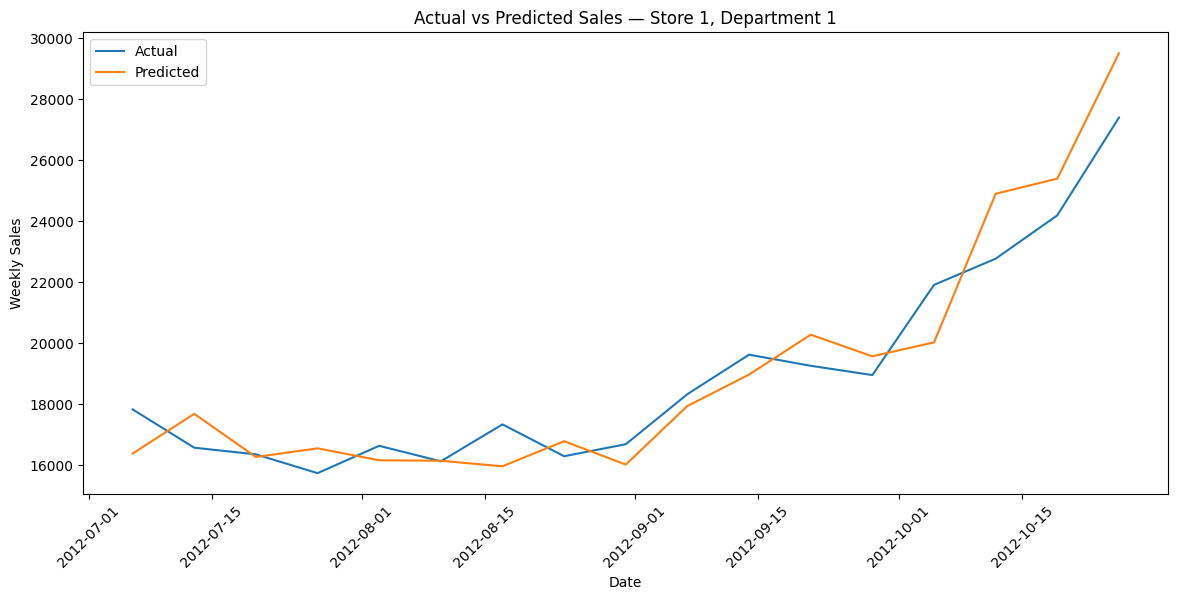

In [114]:
plt.figure(figsize=(14, 6))

plt.plot(
    sample_forecast["Date"],
    sample_forecast["Weekly_Sales"],
    label="Actual"
)

plt.plot(
    sample_forecast["Date"],
    sample_forecast["Predicted_Sales"],
    label="Predicted"
)

plt.title(
    f"Actual vs Predicted Sales — Store {sample_store}, Department {sample_dept}"
)

plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()

plt.xticks(rotation=45)

plt.show()

In [115]:
final_importance = pd.DataFrame({
    "Feature": forecast_features,
    "Importance": final_rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

final_importance

,Feature,Importance
11,Lag_52,0.802506
8,Lag_1,0.147311
12,Rolling_4,0.034480
13,Rolling_12,0.003993
9,Lag_4,0.003522
10,Lag_12,0.002102
1,Dept,0.001591
4,Week,0.001375
6,TimeIndex,0.001303
0,Store,0.000847


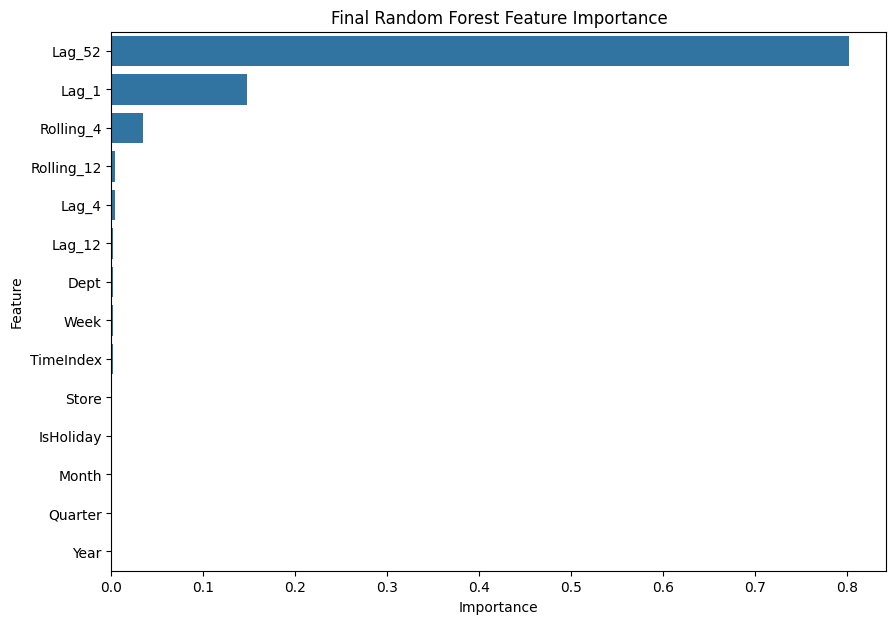

In [116]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=final_importance,
    x="Importance",
    y="Feature"
)

plt.title("Final Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Key Findings

### 1. Historical sales are highly predictive

The forecasting model shows that historical sales are highly informative for predicting future weekly sales.

The `Lag_52` feature was the most important predictor with an importance of approximately **0.803**, indicating that sales from approximately the same week in the previous year provide strong information for forecasting current weekly sales.

### 2. Recent sales also contribute to prediction

The `Lag_1` feature was the second most important predictor with an importance of approximately **0.147**.

This indicates that the most recent week's sales also provide useful information when predicting the next sales period.

### 3. Rolling sales features provide additional information

The `Rolling_4` feature contributed approximately **0.0345** to the model, indicating that short-term historical sales trends provide additional predictive information beyond individual lag values.

### 4. Random Forest outperformed the baseline

The Naive Forecast produced:

- MAE: **1,574.39**
- RMSE: **3,513.11**
- R²: **0.9747**

The Random Forest model improved the results to:

- MAE: **1,226.88**
- RMSE: **2,537.04**
- R²: **0.9868**

This indicates that the machine learning model was able to improve upon the simple previous-sales baseline.

### 5. Random Forest slightly outperformed XGBoost

The model comparison showed:

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Naive Forecast | 1,574.39 | 3,513.11 | 0.9747 |
| Random Forest | **1,226.88** | **2,537.04** | **0.9868** |
| XGBoost | 1,254.22 | 2,587.94 | 0.9862 |

Random Forest achieved the lowest MAE and RMSE as well as the highest R² among the evaluated models.

### 6. Performance remains strong across time-series validation

Using five time-series validation folds, the Random Forest model achieved an average:

- MAE: **1,536.64**
- RMSE: **4,087.79**
- R²: **0.9637**

Although performance varied across folds, the R² remained positive and relatively high in every validation period.

### 7. Forecasting errors vary across periods

The error analysis showed that forecasting performance is not uniform across all time periods.

Some periods produced substantially larger prediction errors than others, suggesting that unusual sales fluctuations or period-specific patterns may be more difficult for the model to capture.

## Business Interpretation

The results indicate that historical sales patterns can be used to support retail planning and forecasting.

The strong contribution of `Lag_52` suggests that yearly recurring sales patterns are important when estimating future demand. Retail businesses can use this information to improve inventory planning, staffing, promotional preparation, and supply allocation.

The contribution of `Lag_1` and rolling features also indicates that recent sales momentum should be considered alongside longer-term seasonal patterns.

However, the presence of larger errors in some periods suggests that historical sales alone may not fully explain sudden changes in demand. Additional variables such as promotions, holidays, weather, economic conditions, and store-specific factors could potentially improve future forecasting performance.

## Conclusion

This project developed a machine learning-based retail sales forecasting system using historical Walmart sales data.

The analysis followed a time-aware workflow consisting of data preparation, temporal feature engineering, lag and rolling features, chronological train-test splitting, baseline forecasting, machine learning model comparison, time-series cross-validation, feature importance analysis, and final forecasting.

Among the evaluated models, **Random Forest** achieved the best holdout performance with an MAE of approximately **1,226.88**, RMSE of approximately **2,537.04**, and R² of approximately **0.9868**.

The model's feature importance analysis showed that `Lag_52` was the dominant predictor, highlighting the importance of annual sales patterns in retail forecasting. Recent sales represented by `Lag_1` also contributed substantially to the prediction.

Time-series cross-validation produced an average R² of approximately **0.9637**, indicating that the model maintained strong predictive performance across different historical periods, although performance varied between folds.

Overall, the project demonstrates how historical sales patterns and time-based feature engineering can be combined with machine learning to support retail demand forecasting and data-driven planning.